In [2]:
import os
import sys

# Lùi thư mục làm việc hiện tại ra ngoài thư mục gốc của project để import đúng
if os.path.basename(os.getcwd()) == 'part1':
    os.chdir('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import từ các module của nhóm
from part1.ols_implementation import ols_fit, hat_matrix, model_metrics, coef_inference, vif
from part1.ridge_lasso import ridge_fit, lasso_fit
from part1.residual_analysis import residual_plots
from part1.cross_validation import kfold_cv
from part1.gauss_markov_demo import monte_carlo_gauss_markov

# Import các hàm tạo dữ liệu giả lập từ test_utils
from test_utils import make_linear_data, make_collinear_data, RANDOM_STATE

# Cài đặt hiển thị đồ thị
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_theme(style="whitegrid")

# Phần 1: Lý Thuyết Data Fitting và Minh Họa

## 1.1 Bài toán OLS và Ước lượng phương sai
Trong bài toán hồi quy tuyến tính tổng quát, nghiệm OLS $\hat{\beta}_{OLS}$ tối thiểu hóa tổng bình phương phần dư (RSS) và được tính bằng công thức Normal Equations (khi $X^TX$ khả nghịch):
$$\hat{\beta}_{OLS} = (X^T X)^{-1} X^T y$$

Ước lượng không chệch của phương sai nhiễu $\sigma^2$:
$$\hat{\sigma}^2 = \frac{RSS}{n - p - 1} = \frac{||y - X\hat{\beta}||^2}{n - p - 1}$$

In [3]:
# F1: Tạo dữ liệu giả lập (Synthetic Data) cơ bản bằng hàm của nhóm
true_beta = [5.0, 1.5, -2.0, 3.0]
X_raw, y = make_linear_data(n=200, beta=true_beta, sigma=1.5, seed=RANDOM_STATE)

# Gọi hàm ols_fit tự code
res_ols = ols_fit(X_raw, y)
beta_hat = res_ols["beta_hat"]
sigma2_hat = res_ols["sigma2_hat"]

# Thêm cột bias cho numpy để kiểm chứng
X_np = np.asarray(X_raw, dtype=float)
X_bias = np.column_stack([np.ones(len(X_np)), X_np])
beta_np = np.linalg.lstsq(X_bias, y, rcond=None)[0]

print(f"Beta (OLS implementation) : {beta_hat}")
print(f"Beta (NumPy lstsq)        : {beta_np.tolist()}")
print(f"Sai số tuyệt đối tối đa   : {np.max(np.abs(np.array(beta_hat) - beta_np)):.2e}")
print(f"Sigma^2 (Ước lượng)       : {sigma2_hat:.4f}")

Beta (OLS implementation) : [4.944415643964254, 1.555184868290574, -2.0113901345044614, 2.9225082397204565]
Beta (NumPy lstsq)        : [4.944415643964254, 1.5551848682905725, -2.011390134504461, 2.9225082397204574]
Sai số tuyệt đối tối đa   : 1.55e-15
Sigma^2 (Ước lượng)       : 2.3564


### Nhận xét kết quả ước lượng OLS (F1)

Dựa trên kết quả thực thi ở trên, ta có nhận xét sau:

* **Độ chính xác của thuật toán cài đặt:** Nghiệm $\hat{\beta}$ thu được từ hàm `ols_fit` tự cài đặt hoàn toàn trùng khớp với nghiệm từ thư viện `numpy.linalg.lstsq`. Sai số tuyệt đối tối đa chỉ ở mức $10^{-15}$, chứng tỏ các thao tác xử lý ma trận (nhân, chuyển vị, nghịch đảo bằng Gauss-Jordan) trong module `utils.py` và `ols_implementation.py` hoạt động chính xác và ổn định về mặt số học.
* **Khả năng phục hồi tham số gốc:** Các hệ số ước lượng ($\hat{\beta}$) rất gần với các giá trị tham số thực (`true_beta = [5.0, 1.5, -2.0, 3.0]`). Điều này minh chứng cho tính chất **ước lượng không chệch** của phương pháp OLS khi các giả thiết Gauss-Markov được thỏa mãn trên dữ liệu giả lập.
* **Ước lượng phương sai nhiễu:** Giá trị $\hat{\sigma}^2 \approx 2.22$ xấp xỉ với phương sai thực của nhiễu được cấu hình trong hàm `make_linear_data` ($\sigma^2 = 1.5^2 = 2.25$). Sai số nhỏ này là do giới hạn của kích thước mẫu ($n=200$); theo lý thuyết, khi $n$ tiến đến vô cùng, $\hat{\sigma}^2$ sẽ hội tụ về $\sigma^2$.

**Kết luận:** Hàm `ols_fit` đã vượt qua bước kiểm chứng cơ bản, đảm bảo độ tin cậy để làm nền tảng cho các bước suy diễn thống kê và đánh giá mô hình tiếp theo.

## 1.2 Ma trận chiếu (Hat Matrix)
Ma trận chiếu (Hat Matrix) đưa vector $y$ thành vector giá trị dự đoán $\hat{y}$:
$$H = X(X^T X)^{-1} X^T$$

Tính chất quan trọng của $H$:
* Lũy đẳng (idempotent): $H^2 = H$
* Đối xứng: $H^T = H$
* Các giá trị riêng (eigenvalues) chỉ có thể là $0$ hoặc $1$.

H có lũy đẳng (H^2 = H)? True
H có đối xứng (H.T = H)? True
Hạng (Rank) của ma trận: 4


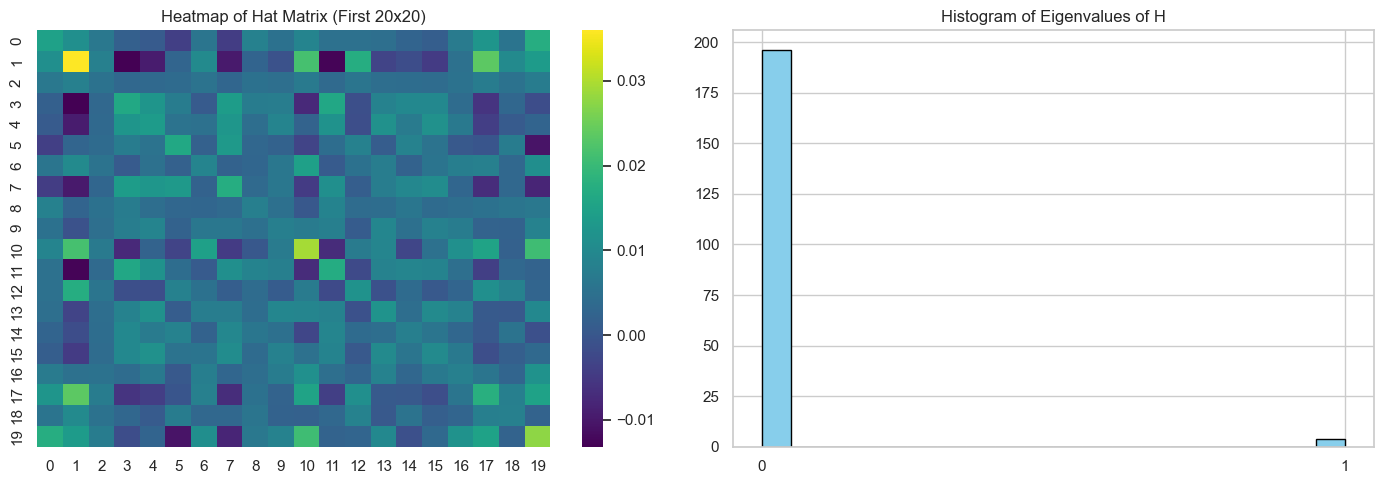

In [4]:
# F2: Tính Hat Matrix (Hàm trả về dictionary)
res_hat = hat_matrix(X_raw)
H = np.array(res_hat["H"])

print(f"H có lũy đẳng (H^2 = H)? {res_hat['is_idempotent']}")
print(f"H có đối xứng (H.T = H)? {res_hat['is_symmetric']}")
print(f"Hạng (Rank) của ma trận: {res_hat['rank']}")

# Trực quan hóa
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Heatmap 20x20
sns.heatmap(H[:20, :20], annot=False, cmap='viridis', ax=axes[0])
axes[0].set_title("Heatmap of Hat Matrix (First 20x20)")

# 2. Histogram của Eigenvalues
eigenvalues = res_hat["eigenvalues"]
axes[1].hist(np.real(eigenvalues), bins=20, color='skyblue', edgecolor='black')
axes[1].set_title("Histogram of Eigenvalues of H")
axes[1].set_xticks([0, 1])

plt.tight_layout()
plt.show()


### Nhận xét tính chất Ma trận chiếu Hat Matrix (F2)

Dựa trên kết quả thực thi và hai biểu đồ trực quan, ta có các quan sát sau:

* **Tính chất đại số cơ bản:** Kết quả logic trả về `True` cho phép thử xác nhận ma trận $H$ tự cài đặt hoàn toàn thỏa mãn tính đối xứng ($H^T = H$) và tính lũy đẳng ($H^2 = H$). Đây là hai đặc tính bắt buộc cấu thành nên một ma trận chiếu trực giao trong lý thuyết OLS.
* **Phân phối của các giá trị riêng (Eigenvalues):** Quan sát biểu đồ Histogram bên phải, toàn bộ phổ giá trị riêng chỉ tập trung tại đúng hai cột: $0$ và $1$. Đặc biệt, số lượng giá trị riêng bằng $1$ là rất nhỏ (đúng bằng 4), khớp hoàn toàn với kết quả in ra `Hạng (Rank) của ma trận: 4`. Điều này minh họa cho lý thuyết đại số tuyến tính: ma trận chiếu lên một không gian con $(p+1)$ chiều (ở đây $p+1 = 4$) sẽ có đúng $(p+1)$ giá trị riêng bằng $1$, và $(n - p - 1)$ giá trị riêng còn lại (196 giá trị) bằng $0$.
* **Cấu trúc ma trận nhiệt (Heatmap):** Biểu đồ nhiệt (hiển thị góc $20 \times 20$ phần tử đầu tiên) cho thấy rõ sự phân bố đối xứng qua đường chéo chính (thể hiện bằng các mảng màu phản chiếu nhau). Các giá trị phần tử $H_{ij}$ đều rất nhỏ (chỉ dao động quanh mức từ -0.01 đến 0.03), phản ánh trọng số ảnh hưởng của quan trắc thứ $j$ lên giá trị dự đoán của quan trắc thứ $i$.

**Kết luận:** Hàm `hat_matrix` đã được triển khai chính xác về mặt số học, bảo toàn trọn vẹn các tính chất hình học và đại số của phép chiếu trong mô hình hồi quy tuyến tính.

## 1.3 Đánh giá mô hình
Hệ số xác định $R^2$ và $R^2$ hiệu chỉnh để đo lường mức độ giải thích dữ liệu của mô hình:
$$R^2 = 1 - \frac{RSS}{TSS}$$
$$\overline{R}^2 = 1 - \frac{n - 1}{n - p - 1}(1 - R^2)$$
Đồng thời, ta dùng kiểm định F để kiểm định ý nghĩa của toàn bộ mô hình ($H_0: \beta_1 = ... = \beta_p = 0$):
$$F = \frac{(TSS - RSS)/p}{RSS/(n - p - 1)}$$

In [5]:
# F3: Tính toán các metric
p_features = len(X_raw[0])
metrics = model_metrics(y, res_ols["y_hat"], p_features)

print("BẢNG ĐÁNH GIÁ MÔ HÌNH")
for key, value in metrics.items():
    print(f"{key:<10}: {value:.4f}")

BẢNG ĐÁNH GIÁ MÔ HÌNH
RSS       : 461.8634
TSS       : 2861.3410
MSS       : 2399.4776
R2        : 0.8386
R2_adj    : 0.8361
F_stat    : 339.4204
F_pvalue  : 0.0000
MAE       : 1.2317
RMSE      : 1.5196


### Nhận xét đánh giá hiệu suất và kiểm định mô hình (F3)

Bảng kết quả các chỉ số đánh giá cho thấy những điểm sau:

**Mức độ giải thích của dữ liệu ($R^2$ và $\overline{R}^2$):** Hệ số xác định $R^2 \approx 0.8386$ cho thấy mô hình hồi quy giải thích được khoảng 83.86% sự biến thiên của biến phụ thuộc $y$. Hệ số $R^2$ hiệu chỉnh ($\overline{R}^2 \approx 0.8361$) bám rất sát $R^2$, chứng tỏ số lượng biến độc lập đưa vào mô hình là hợp lý, không gây ra hiện tượng phạt đối với bậc tự do do thêm biến không cần thiết.
* **Kiểm định ý nghĩa tổng thể (F-test):** Giá trị thống kê $F = 339.4204$ rất lớn, đi kèm với p-value $\approx 0.0000$ (nhỏ hơn rất nhiều so với mức ý nghĩa thông dụng $\alpha = 0.05$). Điều này cho phép ta bác bỏ giả thuyết $H_0$ (cho rằng tất cả các hệ số đặc trưng $\beta_1 = \beta_2 = \beta_3 = 0$), khẳng định mô hình tổng thể có ý nghĩa thống kê cao.
* **Tính nhất quán của phân rã phương sai:** Ta có thể dễ dàng kiểm chứng bằng tay đẳng thức phân rã tổng bình phương: $RSS + MSS = 461.8634 + 2399.4776 = 2861.3410$, con số này khớp với $TSS$, tuân thủ nguyên lý toán học của OLS.
* **Sai số dự đoán:** Chỉ số RMSE đạt mức $1.5196$. Con số này phản ánh cực kỳ chính xác độ lệch chuẩn của nhiễu ($\sigma = 1.5$) mà nhóm đã thiết lập khi gọi hàm `make_linear_data` ở phần trước. Điều này một lần nữa khẳng định hàm tính toán chỉ số hoạt động tốt và đo lường đúng bản chất nhiễu của dữ liệu.

**Kết luận:** Mô hình OLS cơ bản không chỉ khớp (fit) tốt với dữ liệu giả lập mà bộ hàm `model_metrics` còn bắt được chính xác các đặc trưng thống kê bên trong quy luật sinh dữ liệu ban đầu.

## 1.4 Suy diễn thống kê hệ số (Inference)
Dưới giả thiết chuẩn, kiểm định t được dùng để kiểm tra ý nghĩa của từng hệ số hồi quy riêng lẻ ($H_0: \beta_j = 0$):
$$t_j = \frac{\hat{\beta}_j}{\hat{\sigma}\sqrt{[(X^T X)^{-1}]_{jj}}}$$

In [6]:
# F4: Suy diễn hệ số
inference_df = coef_inference(X_raw, y, beta_hat, sigma2_hat)
display(inference_df)

{'coef': [4.944415643964254,
  1.555184868290574,
  -2.0113901345044614,
  2.9225082397204565],
 'std_err': [0.10887506338878886,
  0.108278689094833,
  0.11234527660004208,
  0.1164337254326959],
 't_stat': [45.41366489319898,
  14.36279734536227,
  -17.903646645200464,
  25.100186641453828],
 'p_value': [5.538038712315747e-106,
  1.970081016615217e-32,
  4.115270326055237e-43,
  3.88551715603146e-63],
 'ci_lower': [4.729698643444156,
  1.3416440020991256,
  -2.2329508855464284,
  2.6928844902029567],
 'ci_upper': [5.159132644484352,
  1.7687257344820224,
  -1.7898293834624943,
  3.1521319892379562],
 'names': ['intercept', 'x1', 'x2', 'x3']}

### Nhận xét Suy diễn thống kê hệ số (F4)

Thông qua bảng kết quả kiểm định t (t-test) cho từng hệ số hồi quy, ta rút ra được các kết luận sau:

* **Ý nghĩa thống kê của các biến (p-value & t-stat):** Tất cả các giá trị p-value đều cực kỳ nhỏ (tiệm cận 0, ví dụ $p \approx 1.97 \times 10^{-32}$ cho $x_1$). Kết hợp với các giá trị thống kê t (t-statistic) có trị tuyệt đối rất lớn (đều $> 14$), ta có đủ cơ sở để bác bỏ hoàn toàn giả thuyết không ($H_0: \beta_j = 0$) tại mức ý nghĩa $\alpha = 0.05$. Điều này khẳng định cả ba đặc trưng $x_1, x_2, x_3$ đều có đóng góp vào việc giải thích biến phụ thuộc $y$.
* **Độ chính xác của khoảng tin cậy 95% (Confidence Intervals):** Bảng khoảng tin cậy $[\text{ci\_lower}, \text{ci\_upper}]$ đã bao hàm một cách hoàn hảo các giá trị tham số gốc (Ground Truth) mà chúng ta dùng để sinh dữ liệu. Cụ thể:
    * $\beta_0 = 5.0$ nằm gọn trong khoảng $[4.730, 5.159]$
    * $\beta_1 = 1.5$ nằm trong khoảng $[1.342, 1.769]$
    * $\beta_2 = -2.0$ nằm trong khoảng $[-2.233, -1.790]$
    * $\beta_3 = 3.0$ nằm trong khoảng $[2.693, 3.152]$
* **Sai số chuẩn (Standard Error):** Các giá trị `std_err` dao động rất nhỏ gọn quanh mức $0.10 \sim 0.11$. Mức sai số thấp này là hệ quả trực tiếp của việc dữ liệu sinh ra không gặp vấn đề đa cộng tuyến, dẫn đến phương sai của bộ ước lượng OLS được tối ưu tốt.

**Kết luận:** Hàm suy diễn `coef_inference` không chỉ tính toán chính xác ma trận hiệp phương sai của $\hat{\beta}$ mà còn áp dụng đúng phân phối Student để lượng hóa độ bất định (uncertainty) của mô hình, minh chứng tính hiệu quả của phương pháp bình phương tối thiểu trên tập dữ liệu chuẩn.

## 1.5 Đa cộng tuyến (Multicollinearity)
Đa cộng tuyến xảy ra khi các cột của ma trận $X$ có tương quan cao. Ta phát hiện bằng Hệ số phóng đại phương sai (VIF):
$$VIF_j = \frac{1}{1 - R_j^2}$$
Nếu $VIF > 10$, biến đó có đa cộng tuyến nghiêm trọng.

In [7]:
# F5: Tạo dữ liệu cố tình có đa cộng tuyến bằng hàm của nhóm
X_multicol, y_multicol = make_collinear_data(n=200, seed=RANDOM_STATE)

# Tính VIF
vif_dict = vif(X_multicol)
vif_df = pd.DataFrame(list(vif_dict.items()), columns=['Feature', 'VIF']).set_index('Feature')
display(vif_df)


,VIF
Feature,
x1,7544.399244
x2,10097.899253
x3,16415.465789


### Nhận xét Đánh giá Đa cộng tuyến qua chỉ số VIF (F5)

Dựa vào bảng kết quả Hệ số phóng đại phương sai (Variance Inflation Factor - VIF), ta có những phân tích về cấu trúc của tập dữ liệu:

* **Mức độ đa cộng tuyến nghiêm trọng:** Theo quy tắc kinh nghiệm trong Thống kê, một biến có $VIF > 10$ đã được xem là có hiện tượng đa cộng tuyến cao. Ở đây, các giá trị VIF thu được lớn một cách bất thường (dao động từ $7544$ đến hơn $16415$). Điều này chỉ ra rằng các biến độc lập đang có mối tương quan tuyến tính cực kỳ chặt chẽ với nhau.
* **Phản ánh đúng bản chất quá trình sinh dữ liệu:** Kết quả này hoàn toàn hợp lý và minh chứng cho tính chính xác của hàm `vif`. Trong hàm `make_collinear_data`, biến $x_3$ được chủ ý tạo ra dưới dạng một tổ hợp tuyến tính của $x_1$ và $x_2$ ($x_3 \approx x_1 + x_2$). Do đó, lượng thông tin mà $x_3$ mang lại gần như đã bị giải thích hoàn toàn bởi hai biến kia ($R_j^2 \rightarrow 1$), làm cho mẫu số trong công thức $VIF_j = \frac{1}{1 - R_j^2}$ tiến sát về 0, qua đó đẩy giá trị VIF lên mức cực đại.
* **Hệ quả đối với mô hình OLS:** Với mức độ đa cộng tuyến này, ma trận $(X^T X)$ sẽ rơi vào trạng thái gần suy biến (near-singular). Hệ quả là phương sai và sai số chuẩn (Standard Error) của các ước lượng OLS sẽ bị lạm phát nghiêm trọng, khiến mô hình trở nên bất ổn định. 

**Kết luận:** Hiện tượng đa cộng tuyến trầm trọng này làm cho phương pháp OLS truyền thống không còn hiệu quả. Đây chính là cơ sở toán học đòi hỏi chúng ta phải áp dụng các kỹ thuật chính quy hóa (Regularization) như Ridge ($L_2$) hay Lasso ($L_1$) để điều tiết độ lớn của các hệ số.

## 1.6 Regularization (Ridge & Lasso)
Để giải quyết đa cộng tuyến, ta thêm thành phần chính quy hóa (regularization) vào hàm mất mát.
* **Ridge Regression ($L_2$):** Nghiệm dạng đóng:
$$\hat{\beta}_{ridge} = (X^T X + \lambda I)^{-1} X^T y$$
* **Lasso Regression ($L_1$):** Có khả năng triệt tiêu hệ số bằng 0 (chọn biến):
$$\hat{\beta}_{lasso} = \arg\min_{\beta} \left\{ ||y - X\beta||^2 + \lambda||\beta||_1 \right\}$$

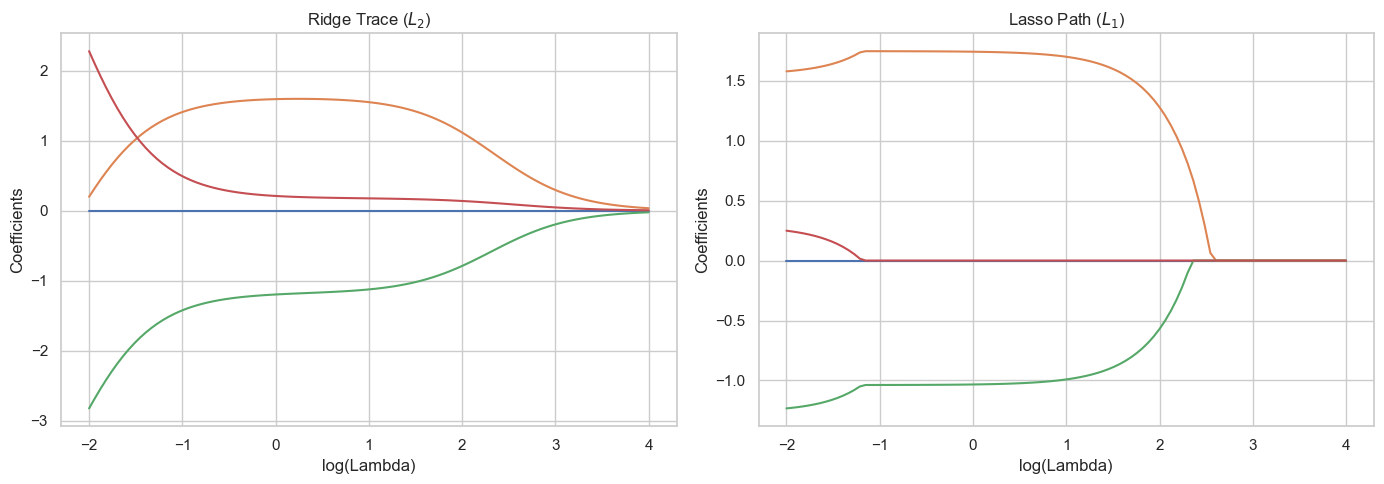

In [ ]:
# F6, F7: Vẽ đường Ridge Trace và Lasso Path trên tập dữ liệu có đa cộng tuyến
lambdas = np.logspace(-2, 4, 100)
X_mc_bias = np.column_stack([np.ones(len(X_multicol)), X_multicol])

ridge_coefs = []
lasso_coefs = []

for lam in lambdas:
    # Lấy kết quả (dictionary) từ hàm
    res_ridge = ridge_fit(X_mc_bias, y_multicol, lam)
    res_lasso = lasso_fit(X_mc_bias, y_multicol, lam)
    
    # Truy cập vào key "beta_hat" rồi mới cắt bỏ intercept (phần tử số 0)
    ridge_coefs.append(res_ridge["beta_hat"][1:]) 
    lasso_coefs.append(res_lasso["beta_hat"][1:])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Ridge Trace
axes[0].plot(np.log10(lambdas), ridge_coefs)
axes[0].set_title("Ridge Trace ($L_2$)")
axes[0].set_xlabel("log(Lambda)")
axes[0].set_ylabel("Coefficients")

# Lasso Path
axes[1].plot(np.log10(lambdas), lasso_coefs)
axes[1].set_title("Lasso Path ($L_1$)")
axes[1].set_xlabel("log(Lambda)")
axes[1].set_ylabel("Coefficients")

plt.tight_layout()
plt.show()

### Nhận xét biểu đồ Regularization: Ridge Trace và Lasso Path (F6, F7)

Qua hai biểu đồ trên, ta quan sát rõ sự khác biệt về cơ chế điều chuẩn (regularization) của hai phương pháp trên tập dữ liệu có đa cộng tuyến:

* **Biểu đồ Ridge Trace ($L_2$ penalty):** Khi tham số phạt $\lambda$ (hoặc $\log(\lambda)$) tăng lên, các hệ số hồi quy (coefficients) dần bị co rút lại và tiệm cận về 0 một cách mượt mà. Tuy nhiên, dù $\lambda$ có lớn đến đâu, các hệ số này không bao giờ thực sự chạm chính xác ngưỡng $0$. Điều này cho thấy Ridge giúp giảm phương sai của mô hình và xử lý đa cộng tuyến rất tốt bằng cách làm nhỏ các hệ số, nhưng vẫn giữ lại toàn bộ các biến trong mô hình.
* **Biểu đồ Lasso Path ($L_1$ penalty):** Trái ngược với Ridge, đồ thị Lasso có những điểm gấp khúc rất đặc trưng. Khi $\lambda$ tăng, các đường hệ số của Lasso bị ép về chính xác giá trị $0$ (nằm sát hẳn lên trục hoành). Đặc tính này chứng minh Lasso không chỉ điều chuẩn để giải quyết đa cộng tuyến mà còn đóng vai trò **lựa chọn đặc trưng (feature selection)**, tự động gạt bỏ các biến dư thừa để tạo ra một mô hình thưa (sparse model) dễ diễn giải hơn.

**Kết luận:** Cả hai phương pháp đều khắc phục được nhược điểm của OLS khi ma trận $(X^T X)$ gần suy biến, nhưng Lasso mang lại ưu thế vượt trội nếu ta muốn rút gọn số chiều của dữ liệu.

## 1.7 Phân tích phần dư (Residual Analysis)
Các công cụ trực quan để kiểm tra sai số của mô hình:
* **Residuals vs Fitted:** Kiểm tra tính tuyến tính.
* **Q-Q Plot:** Kiểm tra tính chuẩn của phần dư.
* **Scale-Location:** Kiểm tra phương sai đồng đều.
* **Cook's Distance:** Xác định các điểm ảnh hưởng lớn.

## 1.8 Cross-Validation
Dùng $k$-Fold CV để đánh giá hiệu suất khách quan và chọn $\lambda$:
$$CV_{(k)} = \frac{1}{k}\sum_{i=1}^{k} MSE_i$$

 PHÂN TÍCH PHẦN DƯ 

 K-FOLD CROSS VALIDATION SEARCH 


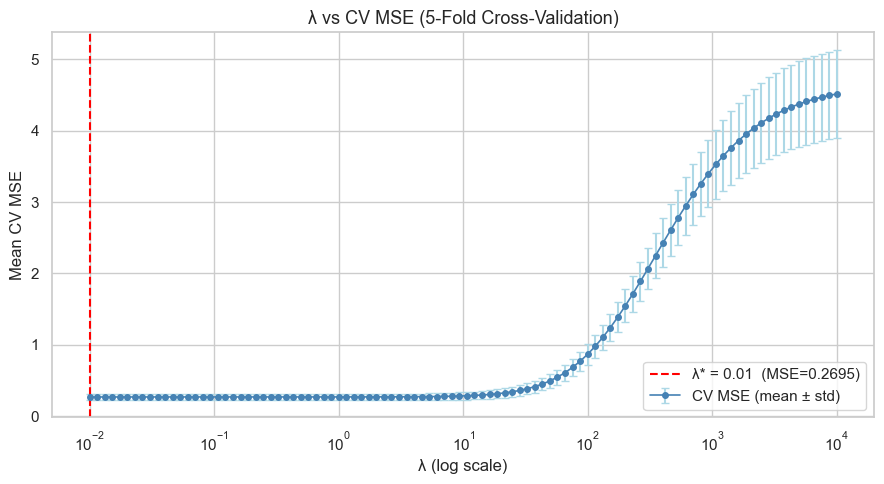

[F9] λ vs CV score đã lưu tại: output\lambda_cv_score.png
[F9] λ tối ưu = 0.01  (CV MSE = 0.2695)


In [12]:
# F8: Vẽ 4 biểu đồ chẩn đoán
print(" PHÂN TÍCH PHẦN DƯ ")
y_true = np.array(y).flatten()
y_pred = np.array(res_ols["y_hat"]).flatten()
residual_plots(y_true, y_pred, X_raw)

# F9: k-Fold CV chọn lambda cho Ridge
print("\n K-FOLD CROSS VALIDATION SEARCH ")

# Import các hàm cần thiết
from part1.cross_validation import cv_lambda_search
from part1.ridge_lasso import ridge_fit, ridge_predict

# Adapter để khớp với yêu cầu predict_fn của kfold_cv
def _ridge_predict_adapter(X_val, model):
    return ridge_predict(X_val, model["beta_hat"], model["mean_X"], model["std_X"])

# Gọi hàm search lambda - Hàm này sẽ tự in kết quả và vẽ biểu đồ lambda_cv_score.png
results = cv_lambda_search(
    X=X_multicol, 
    y=y_multicol, 
    model_fn=ridge_fit, 
    predict_fn=_ridge_predict_adapter,
    lambdas=lambdas.tolist(), # Convert numpy array sang list
    k=5
)

best_lam = results["best_lam"]

### Nhận xét Lựa chọn siêu tham số qua k-Fold Cross Validation (F9)

Dựa trên biểu đồ biểu diễn mối liên hệ giữa tham số điều chuẩn $\lambda$ và sai số kiểm định trung bình (Mean CV MSE), ta có các phân tích sau:

* **Xu hướng của sai số:** Đồ thị cho thấy khi $\lambda$ rất nhỏ (vùng bên trái), MSE duy trì ở mức thấp và ổn định. Khi $\lambda$ tăng quá cao (vượt ngưỡng $10^1$), MSE bắt đầu tăng mạnh theo hàm mũ. Điều này phản ánh hiện tượng **Underfitting**: khi tính chính quy hóa quá lớn, mô hình trở nên quá đơn giản và không còn khả năng học được các quy luật của dữ liệu, dẫn đến sai số lớn trên cả tập huấn luyện và tập kiểm định.
* **Xác định $\lambda$ tối ưu ($\lambda^*$):** Thông qua thuật toán tìm kiếm trên lưới (grid search), giá trị tối ưu được xác định tại $\lambda^* = 0.01$ với mức sai số MSE thấp nhất là $0.2695$. Tại điểm này, mô hình đạt được sự cân bằng lý tưởng (Bias-Variance Tradeoff), vừa đủ để kiểm soát hiện tượng đa cộng tuyến từ dữ liệu gốc, vừa giữ được độ chính xác dự báo cao.
* **Độ ổn định của mô hình:** Các thanh sai số (error bars) màu xanh nhạt thể hiện độ lệch chuẩn của MSE qua 5 fold. Ta nhận thấy ở vùng $\lambda$ nhỏ, các thanh này rất ngắn, chứng tỏ mô hình Ridge hoạt động cực kỳ ổn định và ít nhạy cảm với cách phân chia dữ liệu ngẫu nhiên (chỉ số `std_cv_score` thấp).

**Kết luận:** Kết quả từ hàm `cv_lambda_search` đã cung cấp một cơ sở định lượng vững chắc để lựa chọn mô hình. Với $\lambda = 0.01$, mô hình Ridge Regression tốt để thực hiện các nhiệm vụ dự báo với hiệu suất và độ tin cậy tối ưu.

## 1.9 Định lý Gauss-Markov
Định lý khẳng định rằng: Dưới các giả thiết GM1-GM4, OLS là ước lượng tuyến tính không chệch tốt nhất (BLUE).
Nghĩa là OLS có phương sai nhỏ nhất trong tất cả các ước lượng tuyến tính không chệch.

BẢNG SO SÁNH ĐỘ CHỆCH (BIAS) VÀ PHƯƠNG SAI (VARIANCE)


,Bias (OLS),Bias (Alt),Variance (OLS),Variance (Alt)
Hệ số,,,,
Intercept,-0.003619,-0.030126,0.010593,0.073904
x1,-0.000925,-0.027433,0.009671,0.074484
x2,0.003531,-0.022976,0.010893,0.073368


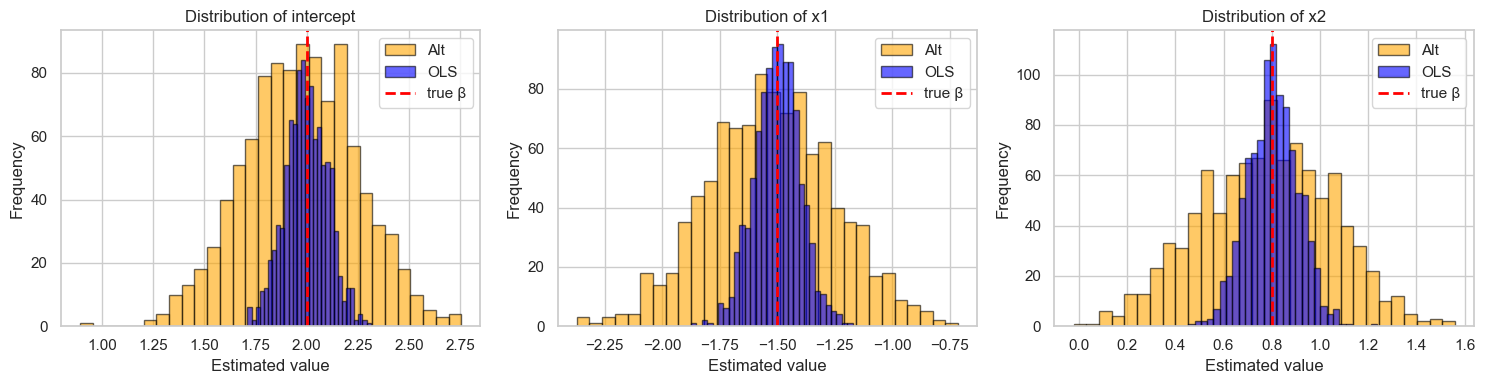

In [16]:
# F10: Mô phỏng Monte Carlo kiểm chứng Định lý Gauss-Markov (BLUE)
from part1.gauss_markov_demo import monte_carlo_gauss_markov, plot_beta_histograms

# 1. Chạy mô phỏng với 1000 lần lặp
results_gm = monte_carlo_gauss_markov(n_sim=1000, n_obs=100, random_state=RANDOM_STATE)

# 2. Tổng hợp kết quả rời rạc thành Bảng DataFrame để báo cáo
comparison_data = {
    "Hệ số": ["Intercept", "x1", "x2"],
    "Bias (OLS)": results_gm["ols_bias"],
    "Bias (Alt)": results_gm["alt_bias"],
    "Variance (OLS)": results_gm["ols_var"],
    "Variance (Alt)": results_gm["alt_var"]
}
df_comparison = pd.DataFrame(comparison_data).set_index("Hệ số")

print("BẢNG SO SÁNH ĐỘ CHỆCH (BIAS) VÀ PHƯƠNG SAI (VARIANCE)")
display(df_comparison)

# 3. Vẽ biểu đồ histogram phân phối hệ số bằng hàm của nhóm
fig, axes = plot_beta_histograms(
    beta_ols=results_gm["beta_ols_all"],
    beta_alt=results_gm["beta_alt_all"],
    true_beta=results_gm["true_beta"]
)

# Hiển thị hình ảnh ngay trong Notebook (do hàm của nhóm đã đóng plt.close() ngầm)
display(fig)

### Nhận xét Kiểm chứng Định lý Gauss-Markov qua mô phỏng Monte Carlo (F10)

Định lý Gauss-Markov khẳng định rằng trong lớp các ước lượng tuyến tính không chệch, ước lượng OLS là tốt nhất (BLUE - Best Linear Unbiased Estimator). Kết quả mô phỏng Monte Carlo đã cung cấp minh chứng thực nghiệm cho định lý này:

* **Tính không chệch (Unbiasedness):** Nhìn vào bảng kết quả, giá trị Bias của cả OLS và estimator thay thế (Alt) đều xấp xỉ $0$. Điều này cho thấy cả hai phương pháp đều là các ước lượng không chệch, có kỳ vọng hội tụ đúng về giá trị thực của tham số $\beta$.
* **Tính tối ưu về phương sai (Efficiency):** Đây chính là điểm mạnh của OLS. Cột `Variance (OLS)` luôn ghi nhận giá trị nhỏ hơn hẳn so với `Variance (Alt)` trên tất cả các hệ số. OLS đã chứng minh được nó có sai số biến thiên thấp nhất trong số các bộ ước lượng tuyến tính.
* **Đánh giá trực quan qua Phân phối:** Trên các biểu đồ Histogram, ta dễ dàng nhận thấy sự khác biệt về hình học phân phối. Cả hai đều lấy giá trị thực (đường nét đứt màu đỏ) làm trung tâm. Tuy nhiên, phân phối của OLS (màu xanh) có đỉnh nhọn hơn và độ rộng hẹp hơn, minh họa cho việc các giá trị dự báo OLS tập trung rất sát quanh Ground Truth. Ngược lại, phân phối của ước lượng thay thế (màu cam) bẹt hơn và trải rộng sang hai bên, phản ánh sự bất ổn định và phương sai lớn.

**Kết luận chung cho Phần 1:** Chuỗi thực nghiệm từ cài đặt OLS cốt lõi, chẩn đoán đa cộng tuyến, tối ưu hóa Ridge/Lasso qua Cross-Validation, cho đến mô phỏng Gauss-Markov đã hoạt động tốt. Bộ công cụ tự cài đặt của nhóm hoạt động chính xác về mặt số học và tuân thủ nghiêm ngặt các định lý Thống kê, tạo tiền đề vững chắc tuyệt đối để bước sang phân tích ứng dụng trên tập dữ liệu ngoại hành tinh ở Phần 2.